<a href="https://colab.research.google.com/github/mj-codes-web/Mental-Health-BERT-Fine-Tuned-Evaluation/blob/main/Mental_Health_BERT_Fine_Tuned_%E2%80%93_Evaluation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [5]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [7]:
import zipfile
import os

zip_path = '/content/drive/MyDrive/archive.zip'
extraction_path = '/content/unzipped_archive'

# Create the directory if it doesn't exist
os.makedirs(extraction_path, exist_ok=True)

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extraction_path)

print(f"Archive extracted to: {extraction_path}")
print("Contents of the unzipped archive:")
for root, dirs, files in os.walk(extraction_path):
    for name in files:
        print(os.path.join(root, name))
    for name in dirs:
        print(os.path.join(root, name))

Archive extracted to: /content/unzipped_archive
Contents of the unzipped archive:
/content/unzipped_archive/mental_health_combined_test.csv
/content/unzipped_archive/mental_heath_unbanlanced.csv
/content/unzipped_archive/mental_heath_feature_engineered.csv


In [8]:
import warnings
warnings.filterwarnings("ignore")

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, balanced_accuracy_score, confusion_matrix, classification_report, roc_curve, auc
from sklearn.inspection import permutation_importance

sns.set_theme(style="whitegrid", context="notebook")

%matplotlib inline

np.random.seed(42)

print("Libraries imported successfully")

Libraries imported successfully


In [12]:
path_test = "/content/unzipped_archive/mental_health_combined_test.csv"

df_test = pd.read_csv(path_test)

print("Test Dataset Shape:", df_test.shape)

print("Test Dataset Head:")
print(df_test.head(), "\n")

df_test[[TEXT_COL, LABEL_COL]].head()

Test Dataset Shape: (992, 2)
Test Dataset Head:
                                                text   status
0  i don't understand whats wrong with me. i don'...  Anxiety
1  usually when i have anxiety just chatting with...  Anxiety
2  well, i've had anxiety and panic syndrome for ...  Anxiety
3  for the most minimal of things, like standing ...  Anxiety
4  i stay away from family and live with my roomm...  Anxiety 



,text,status
0,i don't understand whats wrong with me. i don'...,Anxiety
1,usually when i have anxiety just chatting with...,Anxiety
2,"well, i've had anxiety and panic syndrome for ...",Anxiety
3,"for the most minimal of things, like standing ...",Anxiety
4,i stay away from family and live with my roomm...,Anxiety


In [13]:
label2id = {
    "Anxiety": 0,
    "Depression": 1,
    "Normal": 2,
    "Suicidal": 3,
}

if df_test[LABEL_COL].dtype == object:
    df_test["label_id"] = df_test[LABEL_COL].map(label2id)
    LABEL_COL_NUM = "label_id"
else:
    LABEL_COL_NUM = LABEL_COL

df_test[[TEXT_COL, LABEL_COL, LABEL_COL_NUM]].head()

,text,status,label_id
0,i don't understand whats wrong with me. i don'...,Anxiety,0
1,usually when i have anxiety just chatting with...,Anxiety,0
2,"well, i've had anxiety and panic syndrome for ...",Anxiety,0
3,"for the most minimal of things, like standing ...",Anxiety,0
4,i stay away from family and live with my roomm...,Anxiety,0


In [14]:
import kagglehub

model_root = kagglehub.model_download(
    "priyangshumukherjee/mental-health-bert-fine-tunes/pyTorch/default"
)

print("model_root:", model_root)
print("root contents:", os.listdir(model_root))

model_root: /kaggle/input/mental-health-bert-fine-tunes/pytorch/default/3
root contents: ['README.md', 'mental-health-bert-finetuned']


In [15]:
hf_dir = os.path.join(model_root, "mental-health-bert-finetuned")
print("hf_dir:", hf_dir)
print("hf_dir contents:", os.listdir(hf_dir))

hf_dir: /kaggle/input/mental-health-bert-fine-tunes/pytorch/default/3/mental-health-bert-finetuned
hf_dir contents: ['config.json', 'tokenizer.json', 'tokenizer_config.json', 'pytorch_model.bin', 'model.safetensors', 'special_tokens_map.json', 'vocab.txt']


In [16]:
from transformers import AutoTokenizer, AutoModelForSequenceClassification
import torch

tokenizer = AutoTokenizer.from_pretrained(hf_dir)
model = AutoModelForSequenceClassification.from_pretrained(hf_dir)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)
model.eval()

device

device(type='cpu')

In [17]:
from torch.utils.data import Dataset, DataLoader

class MentalHealthTestDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_length=128):
        self.texts = texts
        self.labels = labels
        self.tokenizer = tokenizer
        self.max_length = max_length

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        text = str(self.texts[idx])
        label = int(self.labels[idx])

        encoding = self.tokenizer(
            text,
            truncation=True,
            padding="max_length",
            max_length=self.max_length,
            return_tensors="pt",
        )

        item = {k: v.squeeze(0) for k, v in encoding.items()}
        item["labels"] = torch.tensor(label, dtype=torch.long)
        return item

test_dataset = MentalHealthTestDataset(
    texts=df_test[TEXT_COL].tolist(),
    labels=df_test[LABEL_COL_NUM].tolist(),
    tokenizer=tokenizer,
    max_length=128,
)

test_loader = DataLoader(
    test_dataset,
    batch_size=32,
    shuffle=False,
)

len(test_dataset)

992

In [18]:
from sklearn.metrics import f1_score, accuracy_score, classification_report

all_preds = []
all_labels = []

model.eval()
with torch.no_grad():
    for batch in test_loader:
        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        labels = batch["labels"].to(device)

        outputs = model(
            input_ids=input_ids,
            attention_mask=attention_mask,
            labels=labels,
        )
        logits = outputs.logits
        preds = torch.argmax(logits, dim=-1)

        all_preds.extend(preds.cpu().tolist())
        all_labels.extend(labels.cpu().tolist())

acc = accuracy_score(all_labels, all_preds)
macro_f1 = f1_score(all_labels, all_preds, average="macro")

print(f"Test Accuracy : {acc:.4f}")
print(f"Test Macro F1 : {macro_f1:.4f}\n")
print("Classification report:")
print(classification_report(all_labels, all_preds, digits=4))

Test Accuracy : 0.8972
Test Macro F1 : 0.8954

Classification report:
              precision    recall  f1-score   support

           0     0.8760    0.8548    0.8653       248
           1     0.8616    0.7782    0.8178       248
           2     0.9380    0.9758    0.9565       248
           3     0.9067    0.9798    0.9419       248

    accuracy                         0.8972       992
   macro avg     0.8956    0.8972    0.8954       992
weighted avg     0.8956    0.8972    0.8954       992



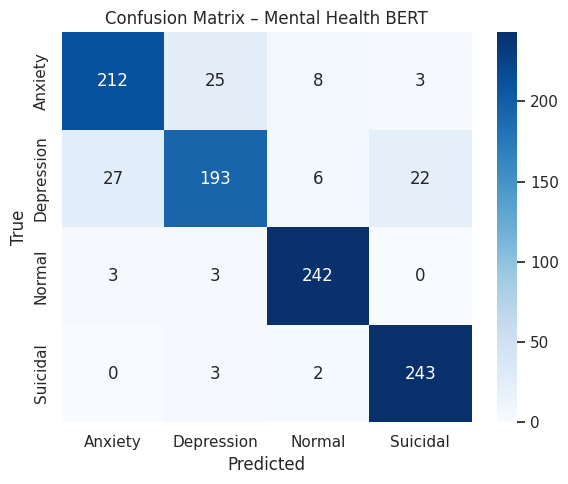

In [19]:
class_names = ["Anxiety", "Depression", "Normal", "Suicidal"]

cm = confusion_matrix(all_labels, all_preds, labels=[0, 1, 2, 3])

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names,
)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix – Mental Health BERT")
plt.tight_layout()
plt.show()

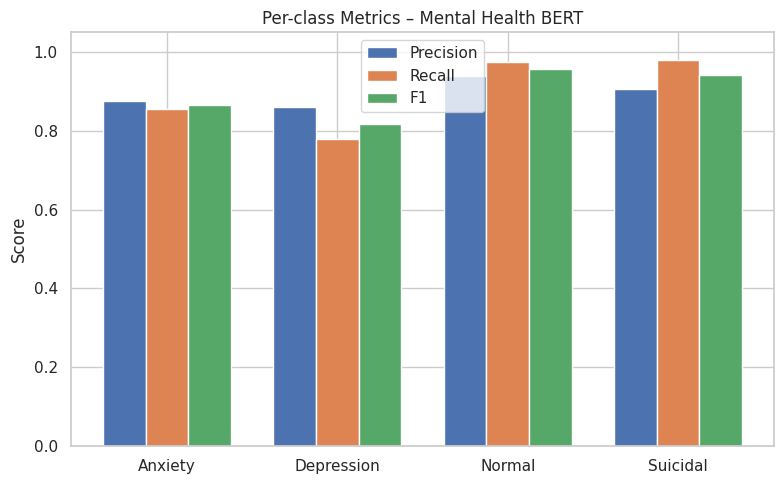

In [20]:
report_dict = classification_report(
    all_labels,
    all_preds,
    target_names=class_names,
    output_dict=True,
)

precisions = [report_dict[c]["precision"] for c in class_names]
recalls    = [report_dict[c]["recall"]    for c in class_names]
f1s        = [report_dict[c]["f1-score"]  for c in class_names]
x = np.arange(len(class_names))
width = 0.25

plt.figure(figsize=(8, 5))
plt.bar(x - width, precisions, width, label="Precision")
plt.bar(x,         recalls,    width, label="Recall")
plt.bar(x + width, f1s,        width, label="F1")

plt.xticks(x, class_names, rotation=0)
plt.ylim(0, 1.05)
plt.ylabel("Score")
plt.title("Per-class Metrics – Mental Health BERT")
plt.legend()
plt.tight_layout()
plt.show()

In [21]:
id2label = {0: "Anxiety", 1: "Depression", 2: "Normal", 3: "Suicidal"}

analysis_df = pd.DataFrame({
    "text": df_test[TEXT_COL].tolist(),
    "true_id": all_labels,
    "pred_id": all_preds,
})
analysis_df["true_label"] = analysis_df["true_id"].map(id2label)
analysis_df["pred_label"] = analysis_df["pred_id"].map(id2label)

# Anxiety ↔ Depression confusions (common failure mode)
mask_confuse_ad = (
    ((analysis_df["true_label"] == "Anxiety") & (analysis_df["pred_label"] == "Depression")) |
    ((analysis_df["true_label"] == "Depression") & (analysis_df["pred_label"] == "Anxiety"))
)

analysis_df[mask_confuse_ad].head(10)

,text,true_id,pred_id,true_label,pred_label
4,i stay away from family and live with my roomm...,0,1,Anxiety,Depression
7,i quit my job today. it was fucking terrible. ...,0,1,Anxiety,Depression
12,"it started off okay, i was answering questions...",0,1,Anxiety,Depression
18,i had a little numbness on my left side of my ...,0,1,Anxiety,Depression
27,i think about death all the time. everything i...,0,1,Anxiety,Depression
33,i feel alone and useless unless i'm high or dr...,0,1,Anxiety,Depression
50,"the older i get, the worse i seem to be at, i ...",0,1,Anxiety,Depression
68,"so the title sums it up. i'm almost 28, all my...",0,1,Anxiety,Depression
72,i'm having a really weird time right now. i'm ...,0,1,Anxiety,Depression
75,i took the first step. i’ve been struggling so...,0,1,Anxiety,Depression


In [22]:
!pip install lime
from lime.lime_text import LimeTextExplainer

explainer = LimeTextExplainer(class_names=class_names)

def predict_proba_lime(texts):
    model.eval()
    enc = tokenizer(
        texts,
        truncation=True,
        padding=True,
        max_length=128,
        return_tensors="pt"
    ).to(device)

    with torch.no_grad():
        outputs = model(**enc)
        probs = torch.softmax(outputs.logits, dim=-1)

    return probs.cpu().numpy()

In [23]:
sample = analysis_df[mask_confuse_ad].iloc[0]

exp = explainer.explain_instance(
    sample["text"],
    predict_proba_lime,
    num_features=8,
    num_samples=200
)

exp.show_in_notebook(text=True)

In [ ]:
import torch.nn.functional as F

all_probs = []

model.eval()
with torch.no_grad():
    for batch in test_loader:
        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)

        outputs = model(
            input_ids=input_ids,
            attention_mask=attention_mask,
        )
        probs = F.softmax(outputs.logits, dim=-1)
        all_probs.append(probs.cpu())

all_probs = torch.cat(all_probs, dim=0).numpy()

plt.figure(figsize=(8, 5))
for i, name in enumerate(class_names):
    plt.hist(
        all_probs[:, i],
        bins=30,
        alpha=0.5,
        label=name,
        range=(0, 1),
    )

plt.xlabel("Predicted probability")
plt.ylabel("Count")
plt.title("Distribution of Predicted Probabilities by Class")
plt.legend()
plt.tight_layout()
plt.show()

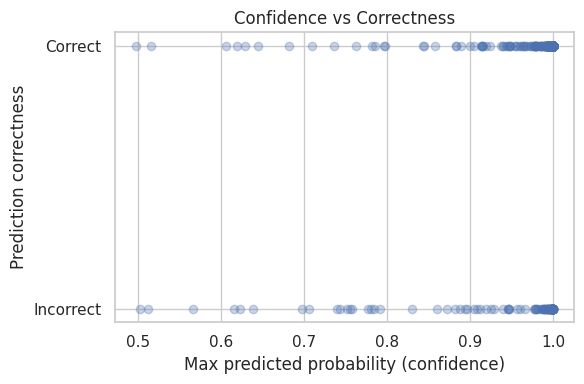

In [25]:
max_confidence = all_probs.max(axis=1)
correct = (np.array(all_preds) == np.array(all_labels))

plt.figure(figsize=(6, 4))
plt.scatter(max_confidence, correct.astype(int), alpha=0.3)
plt.yticks([0, 1], ["Incorrect", "Correct"])
plt.xlabel("Max predicted probability (confidence)")
plt.ylabel("Prediction correctness")
plt.title("Confidence vs Correctness")
plt.tight_layout()
plt.show()

In [26]:
high_conf_errors = analysis_df[
    (max_confidence > 0.8) & (~correct)
]

high_conf_errors.head()

,text,true_id,pred_id,true_label,pred_label
4,i stay away from family and live with my roomm...,0,1,Anxiety,Depression
7,i quit my job today. it was fucking terrible. ...,0,1,Anxiety,Depression
12,"it started off okay, i was answering questions...",0,1,Anxiety,Depression
15,i’ve had the worst week of my life. pretty muc...,0,3,Anxiety,Suicidal
27,i think about death all the time. everything i...,0,1,Anxiety,Depression


In [27]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_auc_score

# Binarize labels for One-vs-Rest ROC-AUC
y_true_bin = label_binarize(all_labels, classes=[0, 1, 2, 3])

# Macro ROC-AUC
roc_auc_macro = roc_auc_score(
    y_true_bin,
    all_probs,
    average="macro",
    multi_class="ovr"
)

# Per-class ROC-AUC
roc_auc_per_class = roc_auc_score(
    y_true_bin,
    all_probs,
    average=None,
    multi_class="ovr"
)

print(f"Macro ROC-AUC (OvR): {roc_auc_macro:.4f}")
for cls, auc_val in zip(class_names, roc_auc_per_class):
    print(f"{cls} ROC-AUC: {auc_val:.4f}")

Macro ROC-AUC (OvR): 0.9771
Anxiety ROC-AUC: 0.9700
Depression ROC-AUC: 0.9488
Normal ROC-AUC: 0.9946
Suicidal ROC-AUC: 0.9949


In [28]:
from sklearn.metrics import average_precision_score

pr_auc_per_class = average_precision_score(
    y_true_bin,
    all_probs,
    average=None
)

pr_auc_macro = average_precision_score(
    y_true_bin,
    all_probs,
    average="macro"
)

print(f"Macro PR-AUC: {pr_auc_macro:.4f}")
for cls, pr in zip(class_names, pr_auc_per_class):
    print(f"{cls} PR-AUC: {pr:.4f}")

Macro PR-AUC: 0.9436
Anxiety PR-AUC: 0.9247
Depression PR-AUC: 0.8752
Normal PR-AUC: 0.9855
Suicidal PR-AUC: 0.9888


In [29]:
from sklearn.metrics import precision_recall_fscore_support

def threshold_analysis(class_id, thresholds):
    print(f"\nThreshold Analysis – {class_names[class_id]}")
    print("Thresh | Precision | Recall | F1")
    print("-" * 35)

    y_true = (np.array(all_labels) == class_id).astype(int)
    probs = all_probs[:, class_id]

    for t in thresholds:
        y_pred = (probs >= t).astype(int)
        p, r, f, _ = precision_recall_fscore_support(
            y_true, y_pred, average="binary", zero_division=0
        )
        print(f"{t:5.2f} | {p:9.3f} | {r:6.3f} | {f:6.3f}")

thresholds = [0.3, 0.4, 0.5, 0.6]

threshold_analysis(1, thresholds)  # Depression
threshold_analysis(3, thresholds)  # Sucidal


Threshold Analysis – Depression
Thresh | Precision | Recall | F1
-----------------------------------
 0.30 |     0.857 |  0.794 |  0.824
 0.40 |     0.863 |  0.786 |  0.823
 0.50 |     0.862 |  0.778 |  0.818
 0.60 |     0.865 |  0.774 |  0.817

Threshold Analysis – Suicidal
Thresh | Precision | Recall | F1
-----------------------------------
 0.30 |     0.900 |  0.984 |  0.940
 0.40 |     0.904 |  0.984 |  0.942
 0.50 |     0.907 |  0.980 |  0.942
 0.60 |     0.910 |  0.980 |  0.944


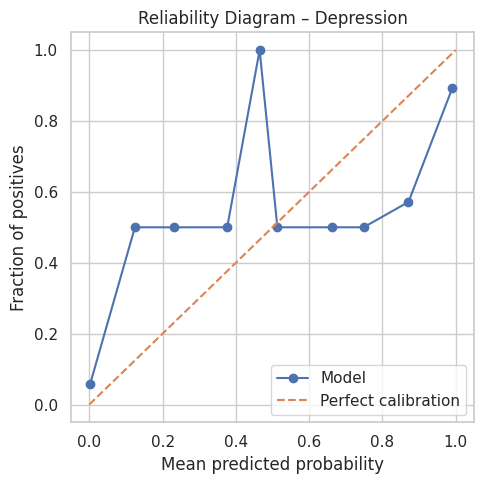

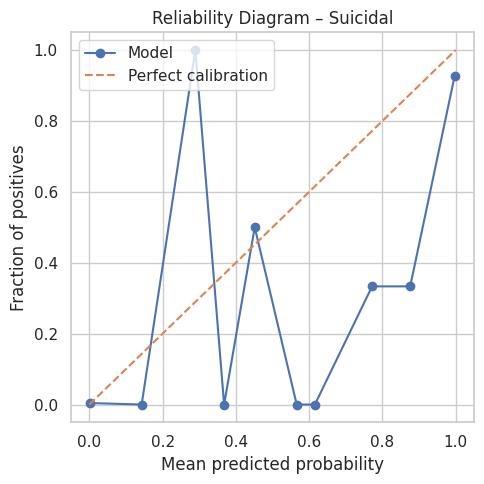

In [30]:
!pip install --upgrade scikit-learn
from sklearn.calibration import calibration_curve

def plot_reliability(class_id, n_bins=10):
    y_true = (np.array(all_labels) == class_id).astype(int)
    probs = all_probs[:, class_id]

    frac_pos, mean_pred = calibration_curve(
        y_true, probs, n_bins=n_bins, strategy="uniform"
    )

    plt.figure(figsize=(5, 5))
    plt.plot(mean_pred, frac_pos, marker="o", label="Model")
    plt.plot([0, 1], [0, 1], linestyle="--", label="Perfect calibration")
    plt.xlabel("Mean predicted probability")
    plt.ylabel("Fraction of positives")
    plt.title(f"Reliability Diagram – {class_names[class_id]}")
    plt.legend()
    plt.tight_layout()
    plt.show()

plot_reliability(1)  # Depression
plot_reliability(3)  # Suicidal

In [32]:
def expected_calibration_error(y_true, probs, n_bins=10):
    bins = np.linspace(0, 1, n_bins + 1)
    ece = 0.0

    for i in range(n_bins):
        mask = (probs >= bins[i]) & (probs < bins[i + 1])
        if np.sum(mask) == 0:
            continue
        acc = np.mean(y_true[mask])
        conf = np.mean(probs[mask])
        ece += np.abs(acc - conf) * np.mean(mask)

    return ece

for cid, name in enumerate(class_names):
    y_true = (np.array(all_labels) == cid).astype(int)
    ece = expected_calibration_error(y_true, all_probs[:, cid])
    print(f"{name} ECE: {ece:.4f}")

Anxiety ECE: 0.0602
Depression ECE: 0.0730
Normal ECE: 0.0225
Suicidal ECE: 0.0263


In [34]:
import torch.nn as nn

class TemperatureScaler(nn.Module):
    def __init__(self):
        super().__init__()
        self.temperature = nn.Parameter(torch.ones(1))

    def forward(self, logits):
        return logits / self.temperature

In [35]:
scaler = TemperatureScaler().to("cpu")

In [36]:
logits_list = []
labels_list = []

model.eval()
with torch.no_grad():
    for batch in test_loader:
        outputs = model(
            input_ids=batch["input_ids"].to(device),
            attention_mask=batch["attention_mask"].to(device)
        )
        logits_list.append(outputs.logits.cpu())
        labels_list.append(batch["labels"].cpu())

logits_tensor = torch.cat(logits_list)      # shape: [N, num_classes]
labels_tensor = torch.cat(labels_list)      # shape: [N]

In [37]:
optimizer = torch.optim.LBFGS(
    [scaler.temperature],
    lr=0.01,
    max_iter=50
)

criterion = nn.CrossEntropyLoss()

def loss_fn():
    optimizer.zero_grad()
    loss = criterion(scaler(logits_tensor), labels_tensor)
    loss.backward()
    return loss

optimizer.step(loss_fn)

print("Learned temperature:", scaler.temperature.item())

Learned temperature: 1.240108847618103


In [38]:
with torch.no_grad():
    scaled_probs = torch.softmax(
        scaler(logits_tensor), dim=-1
    ).numpy()

In [39]:
# Depression misclassified as Anxiety or Suicidal
error_mask = (
    (analysis_df["true_label"] == "Depression") &
    (analysis_df["pred_label"].isin(["Anxiety", "Suicidal"]))
)

analysis_df.loc[error_mask, [
    "text", "true_label", "pred_label"
]].head(10)

,text,true_label,pred_label
248,i'm talking about the kind of people who'd say...,Depression,Anxiety
253,i made it. fuck everyone who put me down. fuck...,Depression,Suicidal
256,i hate the fact that euthanasia is not legal i...,Depression,Suicidal
257,i really let it get out of hand this time folk...,Depression,Anxiety
268,apparently it's not normal to immediately self...,Depression,Anxiety
269,you want certian people to always be there for...,Depression,Suicidal
271,fucking sobbing by myself in the dark because ...,Depression,Anxiety
274,latest update; if the majority wants me to go ...,Depression,Suicidal
276,no special occasion. i just had a tough day at...,Depression,Anxiety
278,"i feel pretty good right now, guys. just a lit...",Depression,Suicidal


In [40]:
id2label = {
    0: "Anxiety",
    1: "Depression",
    2: "Normal",
    3: "Suicidal",
}

example_text = "I've been feeling really overwhelmed and anxious lately."

inputs = tokenizer(
    example_text,
    return_tensors="pt",
    padding=True,
    truncation=True,
    max_length=128,
).to(device)

with torch.no_grad():
    outputs = model(**inputs)
    pred_id = torch.argmax(outputs.logits, dim=-1).item()

print("Text:", example_text)
print("Predicted class:", id2label.get(pred_id, pred_id))

Text: I've been feeling really overwhelmed and anxious lately.
Predicted class: Anxiety


In [47]:
id2label = {
    0: "Anxiety",
    1: "Depression",
    2: "Normal",
    3: "Suicidal",
}

example_text = input("Please enter the text you want to classify: ")

inputs = tokenizer(
    example_text,
    return_tensors="pt",
    padding=True,
    truncation=True,
    max_length=128,
).to(device)

with torch.no_grad():
    outputs = model(**inputs)
    pred_id = torch.argmax(outputs.logits, dim=-1).item()

print("Text:", example_text)
print("Predicted class:", id2label.get(pred_id, pred_id))

Please enter the text you want to classify: i am alone
Text: i am alone
Predicted class: Suicidal
